In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Картинки для тестирования

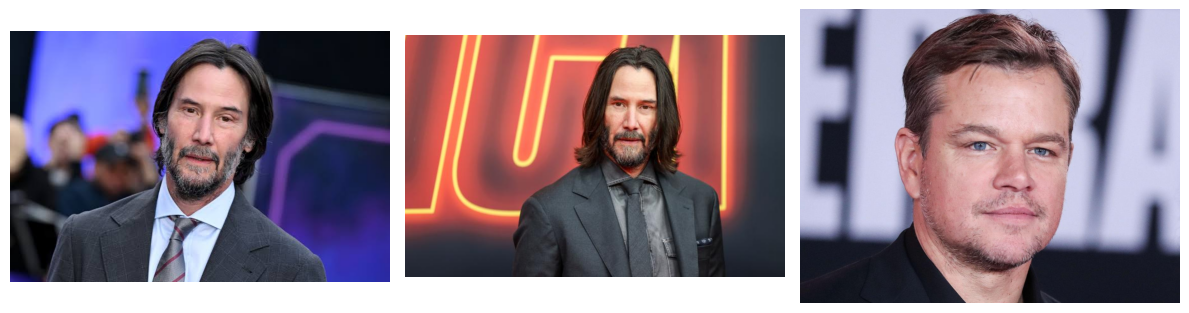

In [ ]:
img1 = Image.open("../data/test_person_1_1.jpg")
img2 = Image.open("../data/test_person_1_2.jpg")
img3 = Image.open("../data/test_person_2_1.jpg")

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img1)
axes[1].imshow(img2)
axes[2].imshow(img3)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# FaceNet

https://github.com/timesler/facenet-pytorch

## Описание

Библиотека facenet-pytorch реализует модель FaceNet (архитектура InceptionResnetV1) и детектор лиц MTCNN в рамках PyTorch
github.com
. Модель обучена на датасете VGGFace2

* Модель сравнительно компактная
* Требует внешнего детектора лиц
* Достаточно быстро работает на CPU

## Установка

```py
# With pip:
pip install facenet-pytorch

# or clone this repo, removing the '-' to allow python imports:
git clone https://github.com/timesler/facenet-pytorch.git facenet_pytorch

# or use a docker container (see https://github.com/timesler/docker-jupyter-dl-gpu):
docker run -it --rm timesler/jupyter-dl-gpu pip install facenet-pytorch && ipython
```

После установки библиотеки необходимо импортировать MTCNN и InceptionResnetV1 и создать экземпляры моделей, а также импортировать другие необходимые зависимости(torch, Image.PIL) и перенести модели на device

In [3]:
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


# Инициализация моделей
mtcnn = MTCNN()
resnet = InceptionResnetV1(pretrained='vggface2').eval()

Во время установки facenet он удалил у меня торч и теперь недоступно cuda..., потому что он ставит старую версию торча с cpu

## Тестирование

In [ ]:
# Загрузка изображений
img1 = Image.open("../data/test_person_1_1.jpg")
img2 = Image.open("../data/test_person_1_2.jpg")
img3 = Image.open("../data/test_person_2_1.jpg")

# Детекция и кадрирование лиц
face1 = mtcnn(img1)
face2 = mtcnn(img2)
face3 = mtcnn(img3)

# Получение эмбеддингов
emb1 = resnet(face1.unsqueeze(0))
emb2 = resnet(face2.unsqueeze(0))
emb3 = resnet(face3.unsqueeze(0))
# Косинусное расстояние
cos1 = torch.nn.functional.cosine_similarity(emb1, emb2)
cos2 = torch.nn.functional.cosine_similarity(emb1, emb3)
print("Косинусное расстояние одного человека:", cos1.item())
print("Косинусное расстояние разных людей:", cos2.item())

Косинусное расстояние одного человека: 0.9315517544746399
Косинусное расстояние разных людей: 0.03540637716650963


# DeepFace

https://github.com/serengil/deepface

## Описание

DeepFace – это «легковесная» Python‑библиотека для распознавания лиц и анализа атрибутов (возраст, пол, эмоции)
. Она объединяет несколько предобученных моделей (VGG‑Face, FaceNet, ArcFace и др.) и автоматически выполняет все стадии: детектирование лица, выравнивание и сравнение
. Главная особенность – очень простой интерфейс: вызов DeepFace.verify(img1, img2) сравнивает две фотографии одной строкой кода.

## Установка

Установка очень простая

```
pip install deepface
```


## Тестирование

Тестирование выполняется также максимально просто, через метод verify, в который передаются пути к двум картинкам

In [7]:
from deepface import DeepFace

In [ ]:
result = DeepFace.verify("../data/test_person_1_1.jpg", "../data/test_person_1_2.jpg")

In [9]:
result

{'verified': True,
 'distance': 0.2772398251379381,
 'threshold': 0.68,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 263,
   'y': 79,
   'w': 184,
   'h': 184,
   'left_eye': (383, 157),
   'right_eye': (325, 144)},
  'img2': {'x': 376,
   'y': 84,
   'w': 147,
   'h': 147,
   'left_eye': None,
   'right_eye': None}},
 'time': 11.71}

In [ ]:
result = DeepFace.verify("../data/test_person_1_1.jpg", "../data/test_person_2_1.jpg")

In [11]:
result

{'verified': False,
 'distance': 0.9103326236122313,
 'threshold': 0.68,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 263,
   'y': 79,
   'w': 184,
   'h': 184,
   'left_eye': (383, 157),
   'right_eye': (325, 144)},
  'img2': {'x': 381,
   'y': 214,
   'w': 558,
   'h': 558,
   'left_eye': (757, 450),
   'right_eye': (560, 432)}},
 'time': 4.4}

# InsightFace

https://insightface.ai/

## Описание

Insightface — open‑source набор инструментов для анализа 2D и 3D изображений, реализованный с помощью фреймворков машинного обучения PyTorch и MXNet. Данная библиотека эффективно реализует широкий спектр современных алгоритмов распознавания/детектирования/выравнивания лиц, которые оптимизированы как для обучения, так и для развертывания. InsightFace позволяет в качестве инференса использовать CPU или GPU. Однако при использовании GPU достигаетсякардинальное (до 100 раз) ускорение работы и крайне высокая эффективность обучения по сравнению с CPU.



## Установка

In [12]:
# !pip install -U insightface

## Тестирование

Импортируем модули

In [7]:
import cv2
from insightface.app import FaceAnalysis

In [14]:
app = FaceAnalysis(providers=['CPUExecutionProvider'])  # или ['CUDAExecutionProvider'] для GPU
app.prepare(ctx_id=0, det_size=(640, 640))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


Все необходимые для работы модели onnx‑файлы будут скачаны и размещены в директории ~/.insightface/models/. В дальнейшем при инициализации модели дополнительные загрузки производиться не будут.

In [ ]:
# Загрузка изображений
img1 = Image.open("../data/test_person_1_1.jpg")
img2 = Image.open("../data/test_person_1_2.jpg")
img3 = Image.open("../data/test_person_2_1.jpg")

# Преобразование PIL → NumPy (BGR → формат OpenCV)
def pil_to_cv2(pil_img):
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

img1_cv = pil_to_cv2(img1)
img2_cv = pil_to_cv2(img2)
img3_cv = pil_to_cv2(img3)

# Получение эмбеддингов
def get_embedding(image_cv):
    faces = app.get(image_cv)
    if not faces:
        raise ValueError("Лицо не найдено")
    return torch.tensor(faces[0].embedding).float()

# Эмбеддинги
emb1 = get_embedding(img1_cv).unsqueeze(0)
emb2 = get_embedding(img2_cv).unsqueeze(0)
emb3 = get_embedding(img3_cv).unsqueeze(0)

cos1 = torch.nn.functional.cosine_similarity(emb1, emb2)
cos2 = torch.nn.functional.cosine_similarity(emb1, emb3)
print("Косинусное расстояние одного человека:", cos1.item())
print("Косинусное расстояние разных людей:", cos2.item())

# Оценка
threshold = 0.5
print("img1 vs img2 →", "Один человек" if cos1 > threshold else "Разные люди")
print("img1 vs img3 →", "Один человек" if cos2 > threshold else "Разные люди")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Косинусное р

# Заключение
Подводя итог, по удобству установки и использованию однозначно побеждает DeepFace, на втором месте InsightFace, и на последнем FaceNet, так как он испортил torch в этом ноутбуке, переустановив его без cuda

## FaceNet
 Это скорее даже не библиотека, а модель. FaceNet не предоставляет встроенных функций для анализа пола, возраста и эмоций, как DeepFace, и не включает детекторы лиц, как InsightFace, — это именно эмбеддер. Он остаётся нормальной основой для кастомных решений, особенно если требуется простота и понятность внутренней логики.

## DeepFace
Эта библиотека предоставляет удобные функции для определения возраста, эмоций и пола. DeepFace подойдёт тем, кто хочет быстро запустить рабочее решение без необходимости вникать в архитектуру моделей. Библиотека отлично подходит для создания прототипов, исследований, курсовых проектов, демо и простых приложений. Однако, из-за своей универсальности и обобщённости, она не такая гибкая и не всегда оптимальна для высоконагруженных или кастомных систем. Также она использует TensorFlow/Keras, что делает её  более тяжеловесной по сравнению с другими решениями.

## Insight Face
Кроме сравнения лиц, он подходит для задач идентификации (поиск в базе), детекции масок, анализа возраста и пола. Подходит тем, кто строит крупную или кастомную систему, где важны высокая точность и возможность настройки всех этапов пайплайна. Однако он требует определённых знаний и усилий при настройке, особенно если нужно интегрировать в собственный код или сервер.